In [1]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc9 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [4]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [5]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

relaxed_param_bounds = {
    "fts": [-200.0, 200.0],
    "t": [1, 200.0],
    "ampc": [0.01, 1.0],
    'ampm': [-10.0, 10.0],
    "ampg": [-10, 10.0],
    "ampw": [0.0, 1.0],
    "d": [0, 200.0],
    "inh_d": [0, 100.0],
    "inh_w": [-10.0, 10.0],
}

In [6]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [7]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [8]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P)

In [9]:
sgcc.load_saved_parameters(optimized_model['final_epoch_params'])

In [10]:
def renorm(sgcc, newbounds):

    dlgn_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[:-2]
    dlgn_lower = tf.reshape(dlgn_bounds[:,0], [1,1,1,-1,1,1])
    dlgn_upper = tf.reshape(dlgn_bounds[:,1], [1,1,1,-1,1,1])

    v1_bounds = tf.convert_to_tensor([x for x in newbounds.values()])[-2:]
    v1_lower = tf.reshape(v1_bounds[:,0], [1,1,1,-1,1,1])
    v1_upper = tf.reshape(v1_bounds[:,1], [1,1,1,-1,1,1])

    params = {
        'dLGN_params': 
            sgcc.variable_transformer(sgcc.params['dLGN_params'], dlgn_lower, dlgn_upper, 'normalize')
        ,
        'V1_params': sgcc.variable_transformer(sgcc.params['V1_params'], v1_lower, v1_upper, 'normalize')
    }

    return params

In [11]:
renormed_params = renorm(sgcc, relaxed_param_bounds)

In [12]:
model = SGCCircuit(relaxed_param_bounds, identify=False)
model.load_saved_parameters(renormed_params)

In [13]:
optimizer = Optimize(sgcc, 1, 0)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000029A9379C190>


In [14]:
loss_decay = optimized_model['loss_decay']
last_epoch = loss_decay[-1]
best = np.where(last_epoch == last_epoch.min())[0][0]
print(f"Index of best parameters: {best}, loss = {last_epoch[best]}")

Index of best parameters: 710, loss = 0.06439208984375


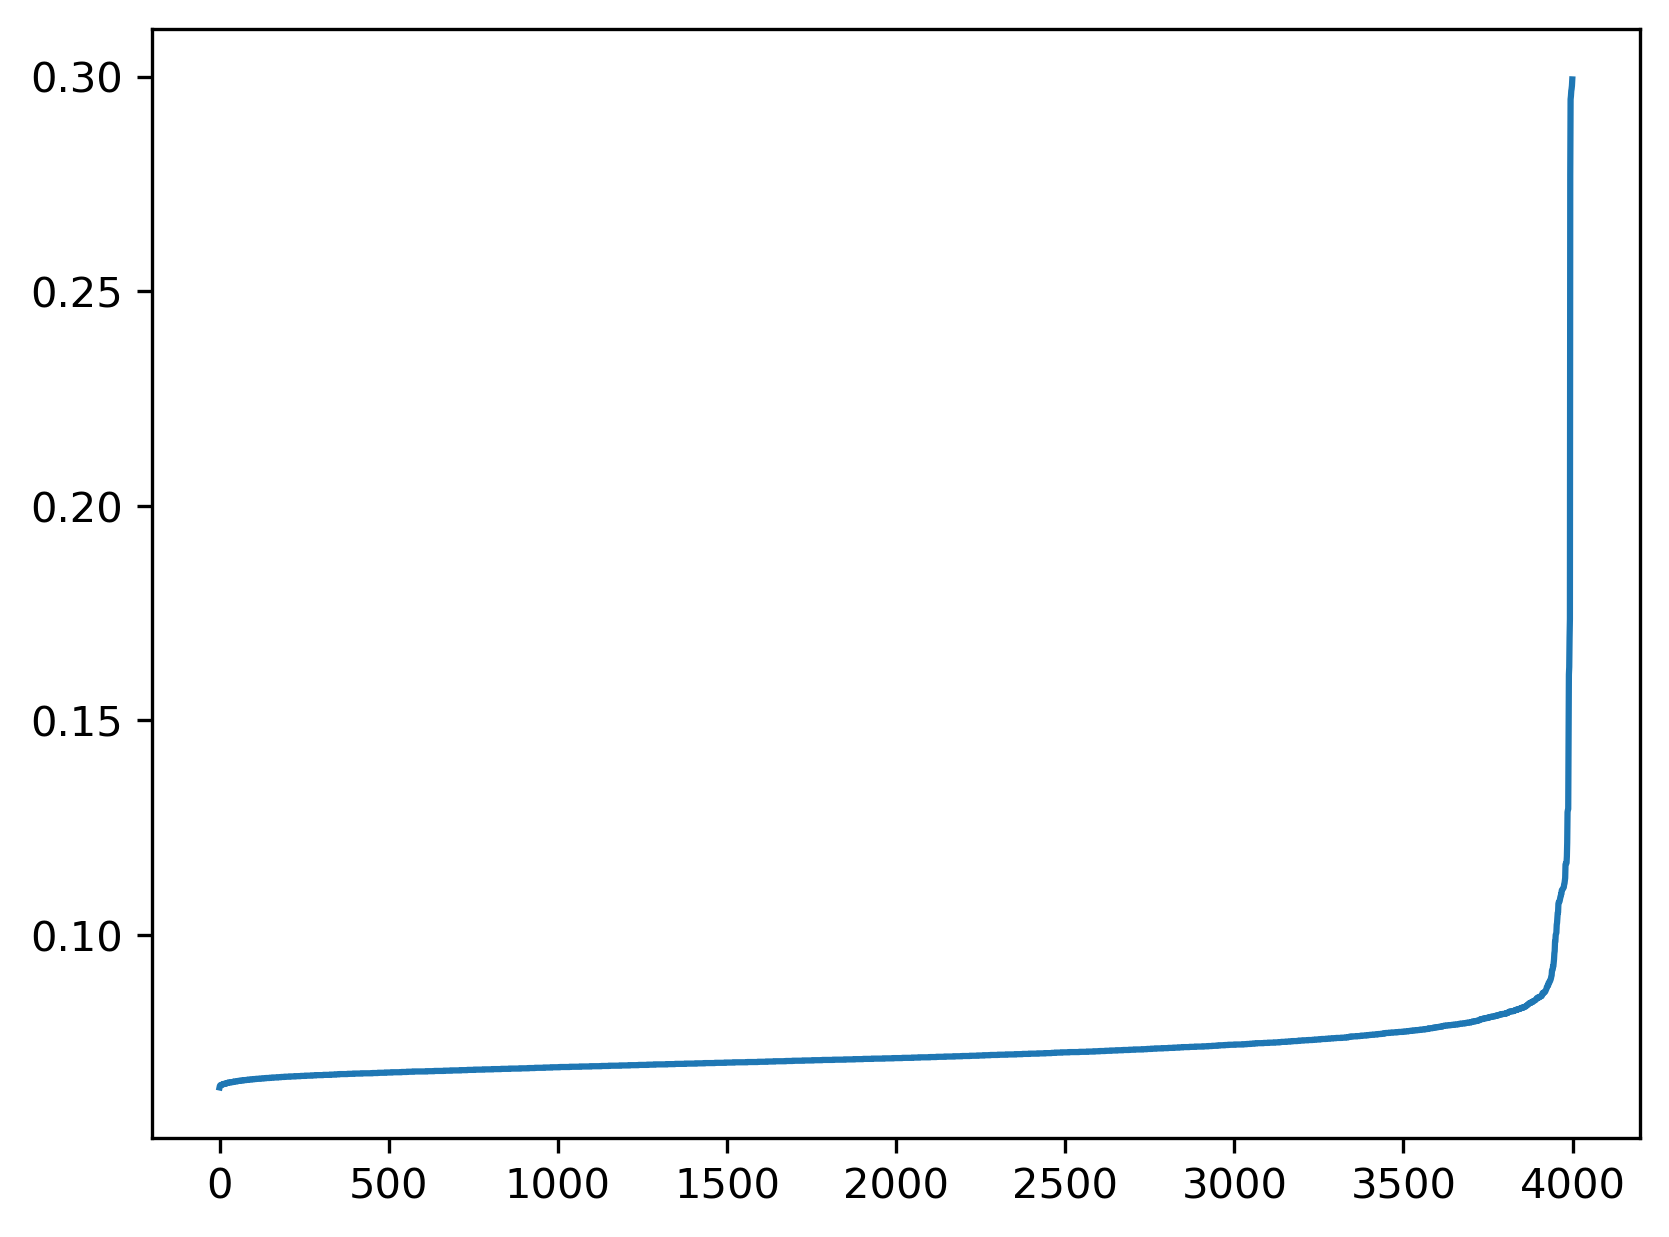

In [27]:
plt.plot(last_epoch[np.argsort(last_epoch)])

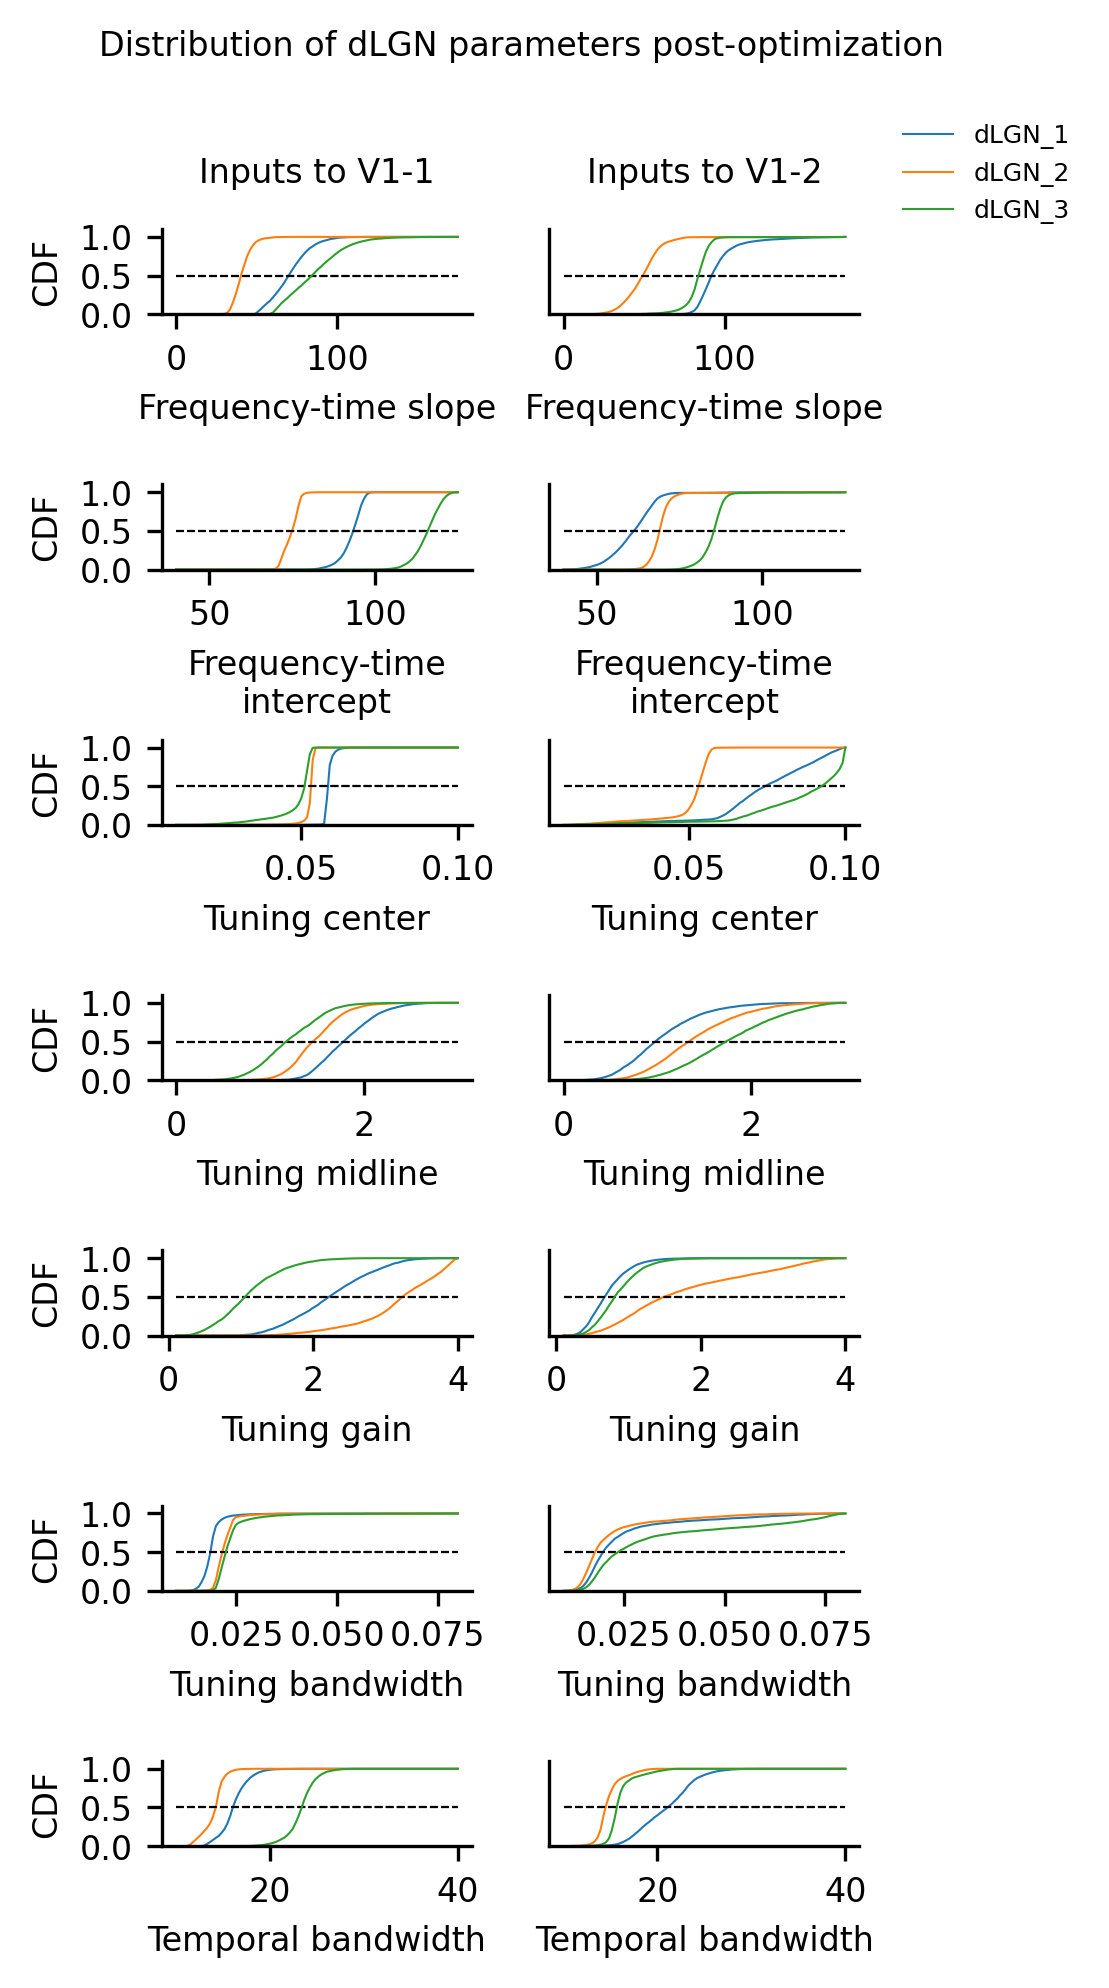

In [15]:
##### The values are right but the appropriate permutation is not applied #####

fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            data = model.params['dLGN_params'][:,u,i,row,0,0]
            x = np.linspace(
                list(param_bounds.values())[:7][row][0],
                list(param_bounds.values())[:7][row][1], 
                100
            )
            kde = ecdf(data).cdf
            y = kde.evaluate(x)

            ymax.append(y.max())

            ax[row, u].plot(x, np.full(len(x), 0.5), '--', color = 'black', linewidth = linewidth)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)

figname = '2d_model_dlgn_param_density_func_first_round.svg'
savepath = v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'figures', figname)
# plt.savefig(savepath, transparent = False, facecolor = 'white',
#            bbox_inches = 'tight', dpi = 300)

In [28]:
## do the parameter sweep

unit = 1
landscapes = np.zeros((2,3,7,100))
for param, key in enumerate(list(relaxed_param_bounds.keys())[:7]):
    val = relaxed_param_bounds[key]
    domain = np.linspace(val[0],val[1], 100).astype(np.float32)
    for dlgn in range(3):
        for v1 in range(2):
            landscape = np.zeros(100)
            for step, v in enumerate(domain):
                model = SGCCircuit(relaxed_param_bounds, identify=False)
                model.load_saved_parameters(renormed_params)
                model.set_parameter(
                    'dLGN',
                    np.argsort(last_epoch)[:1000],
                    [dlgn], [v1],
                    key,
                    v
                )
                Y_pred = model.predict(X)
                landscape[step] = optimizer.mse(Y_pred, Y_true).numpy().mean()
            landscapes[v1, dlgn, param] = landscape

c:\Users\Sturdy\Documents\DebianShared\JC_Lab\Data_exploration\organized_analysis\synnergistic_geniculocortical_circuit_model_project\SGCC\sgcc9.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  transformed = tf.math.log(n/(1-n))


KeyboardInterrupt: 

Text(0.525, 0.975, 'Parameter sweep of the best performing model')

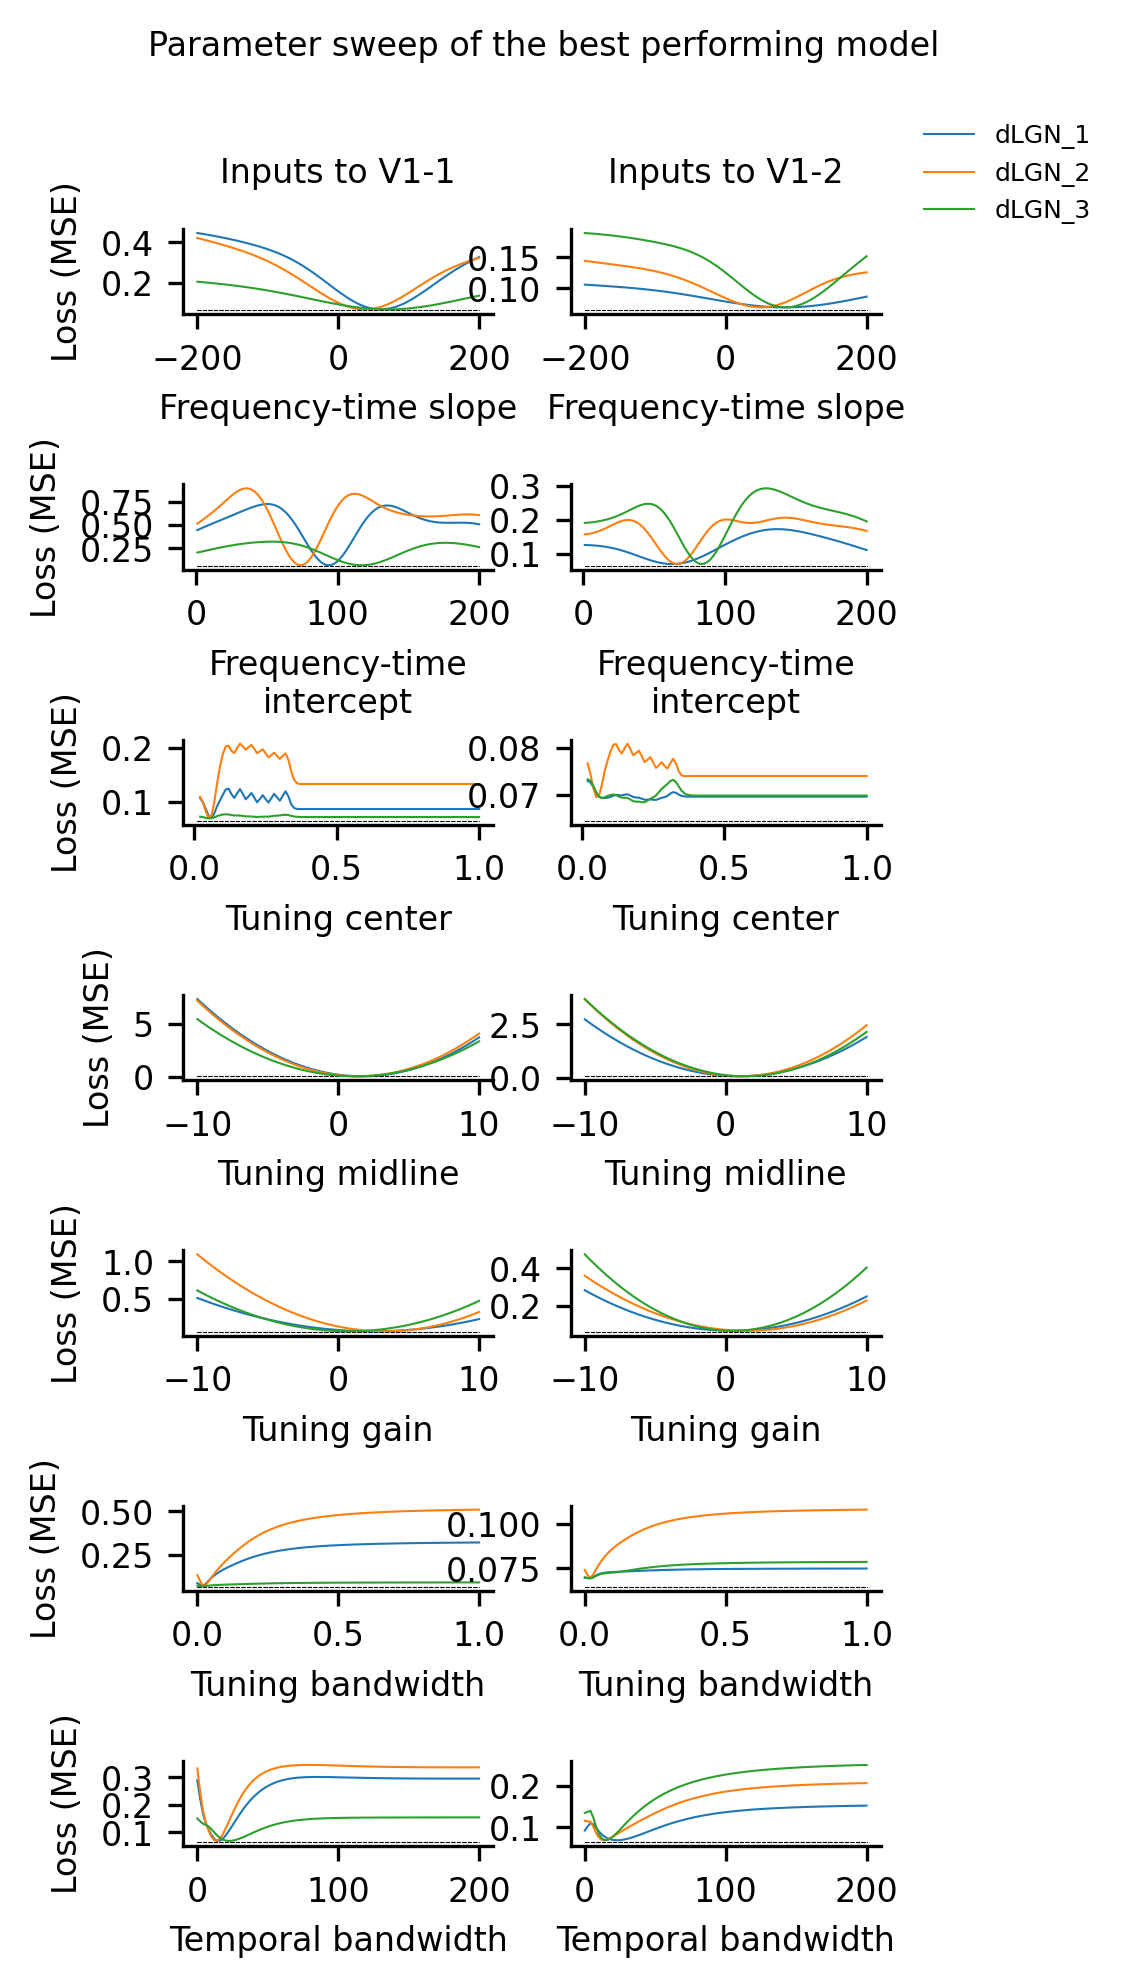

In [21]:
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]\

for row in range(7):
    ymax = []
    ymin = []
    for i in range(3):
        for u in range(2):
            
            key = list(relaxed_param_bounds.keys())[row]
            x = np.linspace(
                relaxed_param_bounds[key][0],
                relaxed_param_bounds[key][1], 
                100
            )

            y = landscapes[u,i,row]
            ymax.append(y[~np.isnan(y)].max())
            ymin.append(y[~np.isnan(y)].min())

            ax[row, u].plot(x, np.full(len(x), last_epoch[best]), '--', color = 'black', linewidth = 0.25)
            ax[row, u].plot(x, y, label = neuron_labels[i], linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("Loss (MSE)", fontsize = fontsize)
    for u in range(2):
        # ax[row, u].set_ylim(
        #     0, 
        #     np.max(ymax) + np.max(ymax)*0.15
        # )
        # ax[row, 1].set_yticks([])
        #ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Parameter sweep of the best performing model", fontsize = fontsize, x = 0.525, y = 0.975)

In [35]:
x = np.arange(0.02,0.34,0.02)

In [36]:
def gaussian(
    support, # domain of the function
    ctr, # mean of the function
    mid, # midline of the function
    amp, # amplitude of the function
    std # bandwidth parameter
):

    f = np.exp(-1*(((support-ctr)**2)/(2*std**2)))

    return mid+(amp*f)

In [37]:
model = SGCCircuit(relaxed_param_bounds, identify=False)
model.load_saved_parameters(renormed_params)
# model.set_parameter(
#     'dLGN',
#     [best],
#     [2], [1],
#     'ampc',
#     p
# )
Y_pred = model.predict(X)

Text(0.5, 1.15, 'V1 Neuron 2 (Low latency unit)')

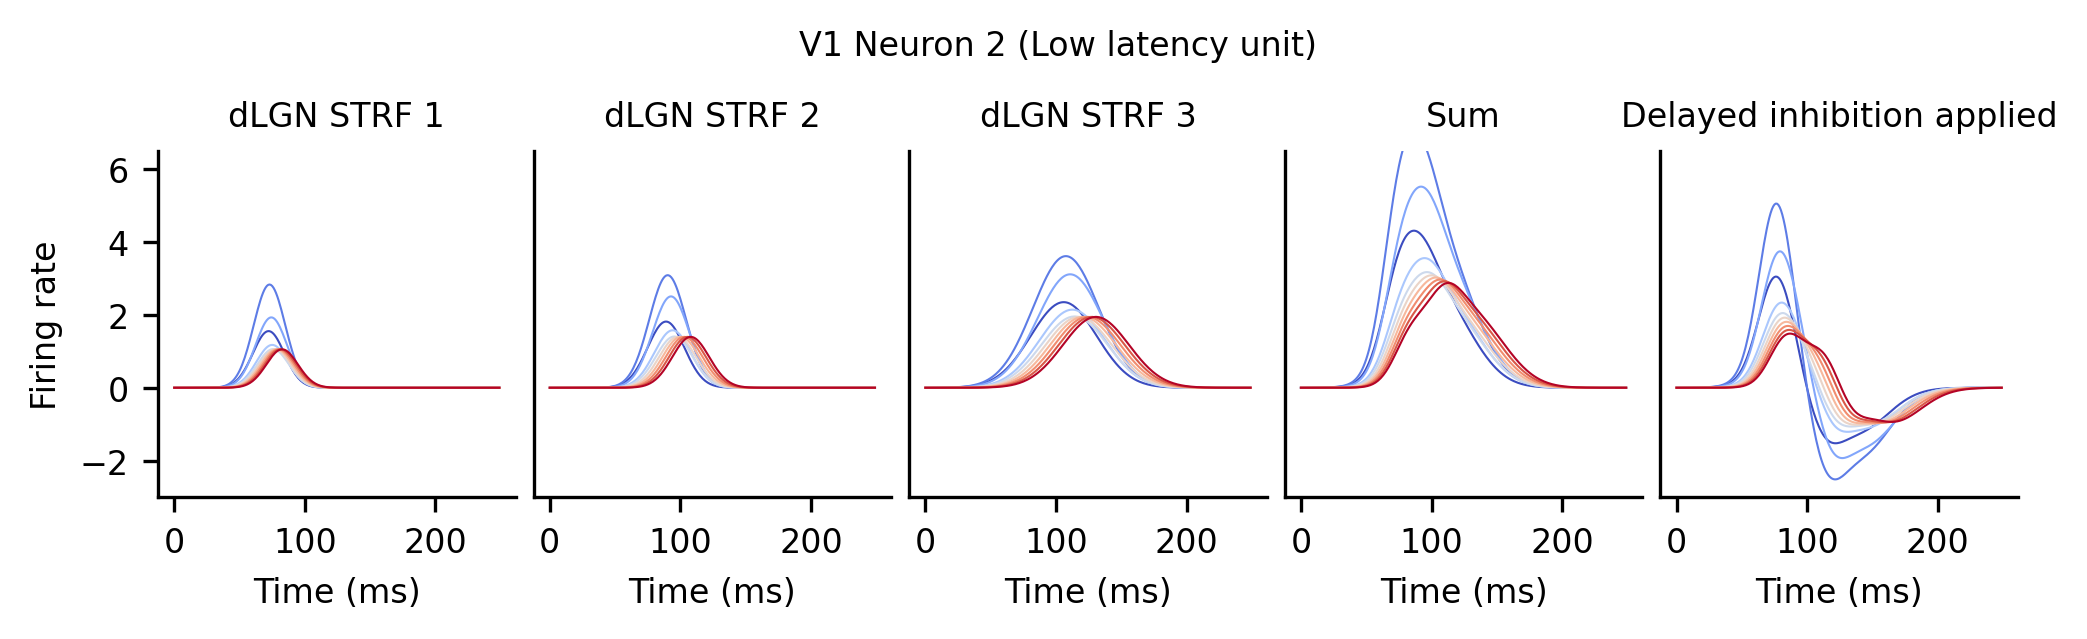

In [38]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][0,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][0,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][0,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][0].numpy().T, linewidth = linewidth)
ax[4].plot(Y_pred[best][0].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)

Text(0.5, 1.15, 'V1 Neuron 2 (Low latency unit)')

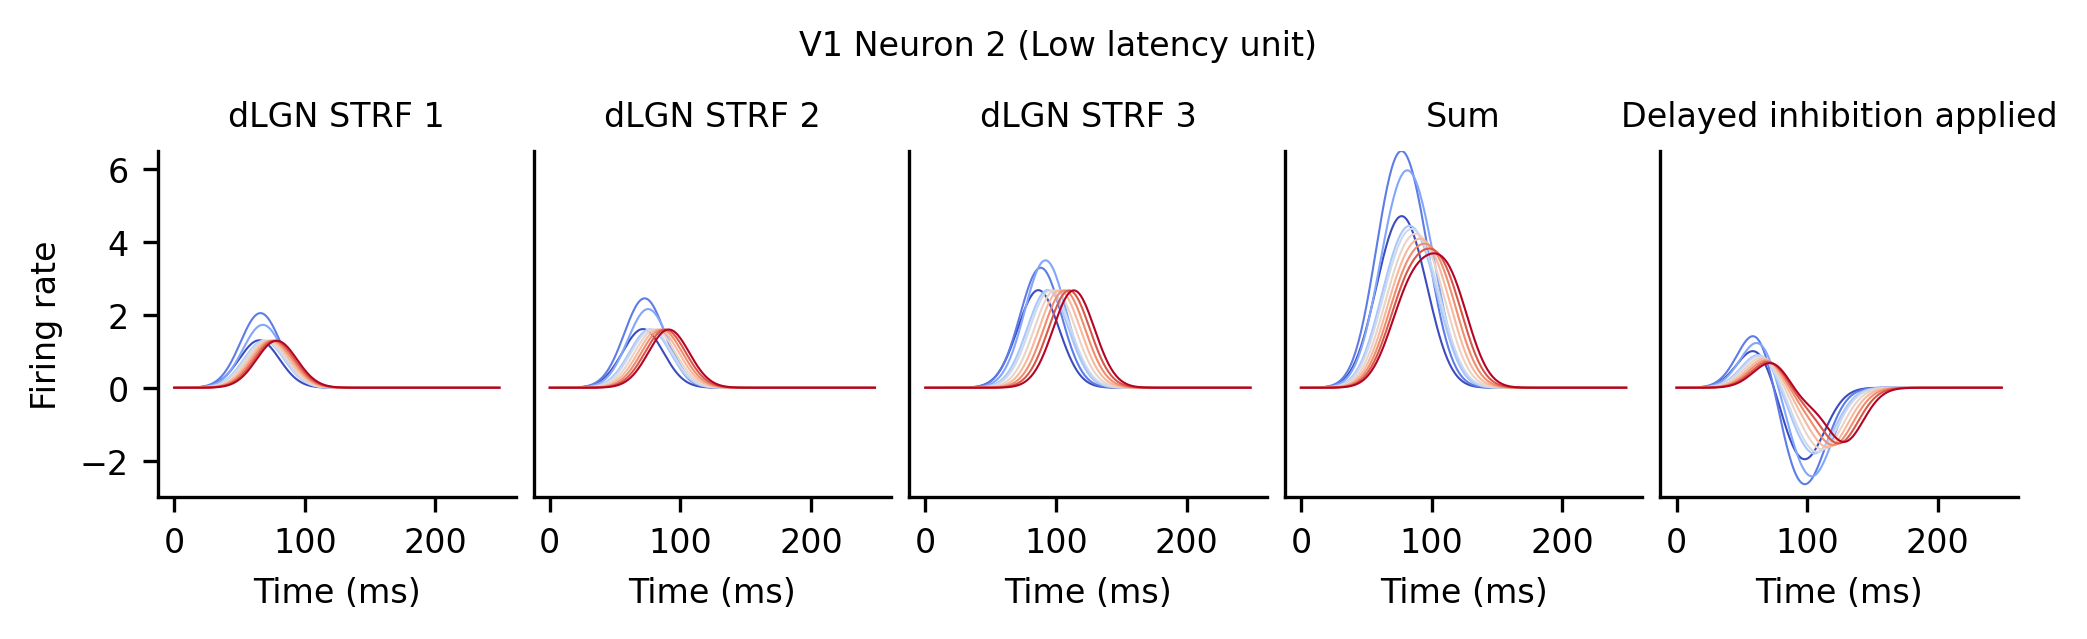

In [39]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][1,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][1,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][1].numpy().T, linewidth = linewidth)
ax[4].plot(Y_pred[best][1].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)

Text(0.5, 1.025, 'dLGN_3 into V1_2')

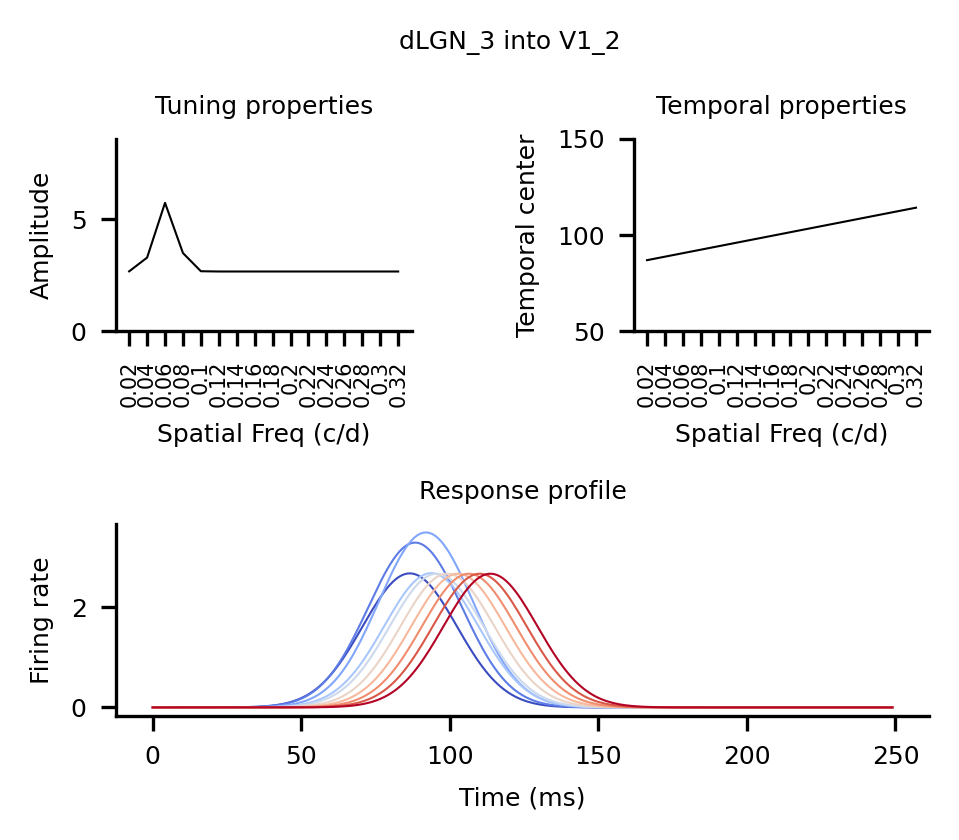

In [40]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 1, 2, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 1, 2, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_3 into V1_2", fontsize = 6, y = 1.025)


In [28]:
model = SGCCircuit(relaxed_param_bounds, identify=False)
model.load_saved_parameters(renormed_params)
model.set_parameter(
    'dLGN',
    [best],
    [2], [1],
    'ampc',
    p
)
Y_pred = model.predict(X)

Text(0.5, 1.15, 'V1 Neuron 2 (Low latency unit)')

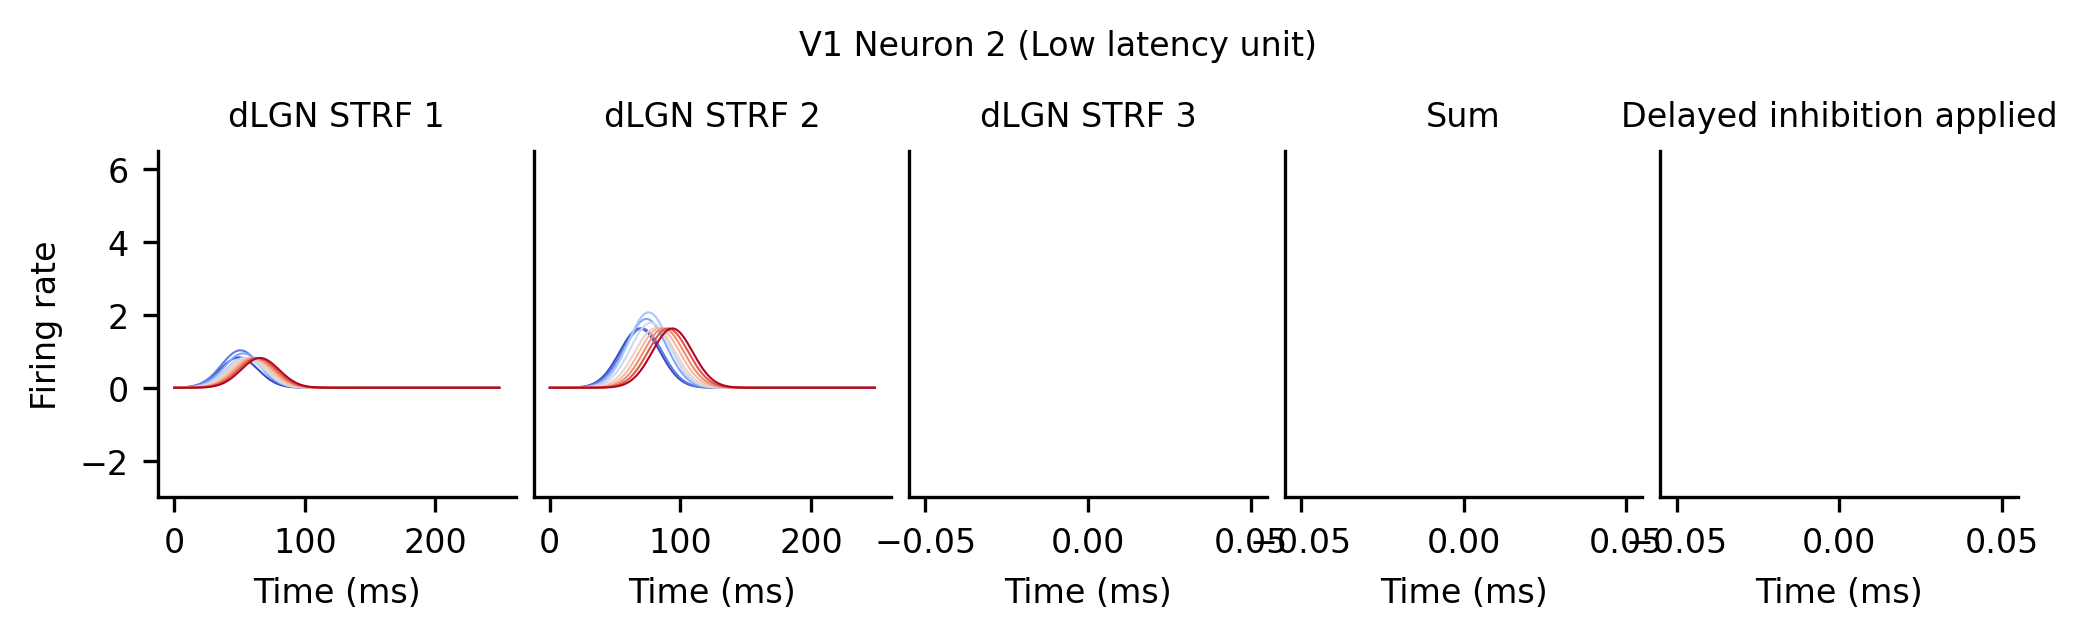

In [29]:
cmap = plt.get_cmap('coolwarm') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(1,5, figsize = (8,1.5))

ax[0].plot(model.dlgn_exc[best][1,0].numpy().T, linewidth = linewidth)
ax[1].plot(model.dlgn_exc[best][1,1].numpy().T, linewidth = linewidth)
ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)
ax[3].plot(model.v1_exc[best][1].numpy().T, linewidth = linewidth)
ax[4].plot(Y_pred[best][1].numpy().T, linewidth = linewidth)

for i in range(5):
    if i>0:
        ax[i].set_yticks([])
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = fontsize)
    ax[i].set_ylim(-3,6.5)
    ax[i].set_xlabel("Time (ms)", fontsize = fontsize)

fig.subplots_adjust(wspace=0.05)
ax[0].set_ylabel("Firing rate", fontsize = fontsize)

ax[0].set_title("dLGN STRF 1", fontsize = fontsize)
ax[1].set_title("dLGN STRF 2", fontsize = fontsize)
ax[2].set_title("dLGN STRF 3", fontsize = fontsize)
ax[3].set_title("Sum", fontsize = fontsize)
ax[4].set_title("Delayed inhibition applied", fontsize = fontsize)

plt.suptitle("V1 Neuron 2 (Low latency unit)", y = 1.15, fontsize = fontsize)

ValueError: Axis limits cannot be NaN or Inf

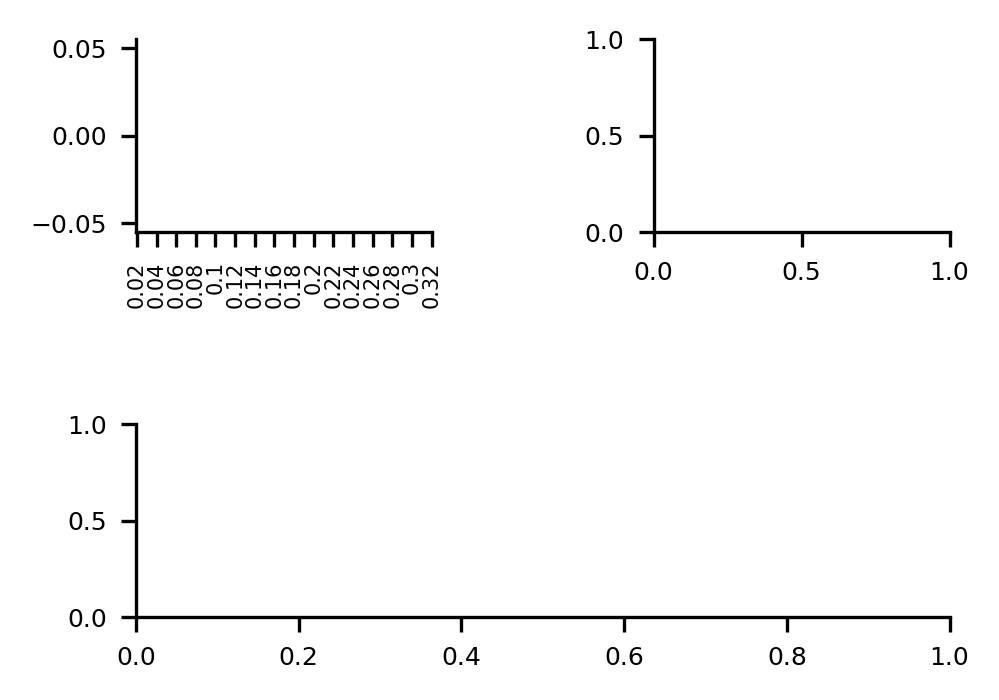

In [30]:
fig = plt.figure(figsize=(3.5, 2.5))
grid = plt.GridSpec(2, 2, hspace=1, wspace=0.75)

ax = [
    fig.add_subplot(grid[:1, 0]),
    fig.add_subplot(grid[:1,1]),
    fig.add_subplot(grid[1:,:]),
]

for i in range(3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(labelsize = 6)

tuning_params = model.params['dLGN_params'][best, 1, 2, 2:6, 0,0].numpy()
time_params = model.params['dLGN_params'][best, 1, 2, :2, 0,0].numpy()

tuning_curve = gaussian(x,*tuning_params)
ctf_line = x*time_params[0]+time_params[1]

ax[0].plot(tuning_curve, linewidth = linewidth, color = 'black')
ax[0].set_xticks(np.arange(16))
ax[0].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[0].set_ylim(0, tuning_curve.max()+tuning_curve.max()*0.5)

ax[1].plot(ctf_line, linewidth = linewidth, color = 'black')
ax[1].set_xticks(np.arange(16))
ax[1].set_xticklabels(x.round(2), fontsize = 5, rotation = 90)
ax[1].set_ylim(50,150)

ax[2].plot(model.dlgn_exc[best][1,2].numpy().T, linewidth = linewidth)

ax[0].set_title("Tuning properties", fontsize = 6)
ax[0].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[0].set_ylabel("Amplitude", fontsize = 6)
ax[1].set_xlabel("Spatial Freq (c/d)", fontsize = 6)
ax[1].set_ylabel("Temporal center", fontsize = 6)
ax[1].set_title("Temporal properties", fontsize = 6)
ax[2].set_title("Response profile", fontsize = 6)
ax[2].set_xlabel("Time (ms)", fontsize = 6)
ax[2].set_ylabel("Firing rate", fontsize = 6)

plt.suptitle("dLGN_3 into V1_2", fontsize = 6, y = 1.025)
